In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
train=pd.read_csv("C:/Users/HP/Downloads/cleaned hotel booking datasets/Hotel_A_Train_Cleaned (4).csv")

In [3]:
val=pd.read_csv("C:/Users/HP/Downloads/cleaned hotel booking datasets/Hotel_A_Validation_Cleaned (3).csv")

## Data Spliting

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
# Define the features and the target
ftrain = train.drop(['Reservation-id','Expected_checkin', 'Expected_checkout', 'Booking_date'], axis=1)

fval = val.drop(['Reservation-id', 'Expected_checkin', 'Expected_checkout', 'Booking_date'], axis=1)


In [ ]:
target_var = "Reservation_Status"
X_train = ftrain.drop(columns=[target_var])
y_train = ftrain[target_var]

X_valtrain = fval.drop(columns=[target_var])
y_valtrain = fval[target_var]

In [ ]:
# Convert to one-hot encoding
y_train_cat = to_categorical(y_train)
y_validation_cat = to_categorical(y_valtrain)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_valtrain = scaler.transform(X_valtrain)

In [ ]:
# Compute class weights to handle imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))

class_weights_dict

{0: np.float64(0.43305734732518214),
 1: np.float64(2.189954560207725),
 2: np.float64(4.269735801297263)}

In [ ]:
def f1_macro(y_true, y_pred):
    y_pred_labels = tf.argmax(y_pred, axis=1)
    y_true_labels = tf.argmax(y_true, axis=1)

    # True positives, predicted positives, actual positives
    tp = tf.math.count_nonzero(y_pred_labels * y_true_labels, dtype=tf.float32)
    predicted_positives = tf.math.count_nonzero(y_pred_labels, dtype=tf.float32)
    actual_positives = tf.math.count_nonzero(y_true_labels, dtype=tf.float32)

    precision = tp / (predicted_positives + 1e-8)
    recall = tp / (actual_positives + 1e-8)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
    return f1

In [ ]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(4, activation='softmax')
])

In [ ]:
# Compiling model with categorical cross entropy
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=[f1_macro]
)

In [ ]:
# Training the model with class weights
history = model.fit(
    X_train,
    y_train_cat,
    validation_data=(X_valtrain, y_validation_cat),
    epochs=50,
    batch_size=64,
    class_weight=class_weights_dict
)

Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - f1_macro: 0.8300 - loss: 3.4049 - val_f1_macro: 1.0000 - val_loss: 1.0502
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - f1_macro: 1.0000 - loss: 1.7735 - val_f1_macro: 1.0000 - val_loss: 1.0900
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - f1_macro: 1.0000 - loss: 1.6638 - val_f1_macro: 1.0000 - val_loss: 1.0836
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - f1_macro: 1.0000 - loss: 1.6829 - val_f1_macro: 1.0000 - val_loss: 1.0820
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - f1_macro: 1.0000 - loss: 1.6692 - val_f1_macro: 1.0000 - val_loss: 1.0754
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - f1_macro: 1.0000 - loss: 1.6655 - val_f1_macro: 1.0000 - val_loss: 1.0776
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - f1_macro: 1.0000 - loss: 1.6385 - val_f1_macro: 1.0000 - val_loss: 1.0797
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - f1_macro: 1.0000 - loss: 1.6395 - val_f1_macro: 

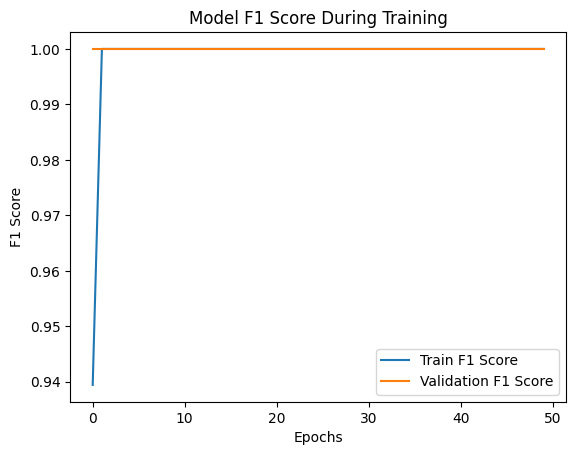

In [ ]:
# accuracy curves
plt.plot(history.history['f1_macro'], label='Train F1 Score')
plt.plot(history.history['val_f1_macro'], label='Validation F1 Score')

plt.title('Model F1 Score During Training')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector.fit(X_train, y_train)

# get feature importances
importances = rf_selector.feature_importances_
indices = np.argsort(importances)[::-1]

# top_features list
top_15_indices = indices[:15]
top_features = X_train.columns[top_15_indices].tolist()

print(top_features)

# Filter datasets
X_train_reduced = X_train[top_features]
X_val_reduced = X_val[top_features]

['Lead_Time', 'Room_Rate', 'Age', 'Checkin_Month', 'Discount_Rate', 'Total_Guests', 'Length_of_Stay', 'Adults', 'Children', 'Meal_Type_FB', 'Babies', 'Gender_M', 'Country_region_SOUTH', 'Required_Car_Parking_YES', 'Booking_channel_ONLINE']


In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize the model
log_reg = LogisticRegression(multi_class='multinomial',
                             solver='lbfgs',
                             class_weight='balanced',
                             max_iter=1000,
                             random_state=42)

# Train the model
log_reg.fit(X_train_reduced, y_train)

# Make predictions on the validation set
y_pred_log = log_reg.predict(X_val_reduced)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(f"Logistic Regression Accuracy: {accuracy_score(y_val, y_pred_log):.2%}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred_log))


Logistic Regression Accuracy: 46.25%

Classification Report:
              precision    recall  f1-score   support

           1       0.60      0.67      0.63      1602
           2       0.28      0.14      0.19       738
           3       0.15      0.21      0.18       393

    accuracy                           0.46      2733
   macro avg       0.34      0.34      0.33      2733
weighted avg       0.45      0.46      0.45      2733



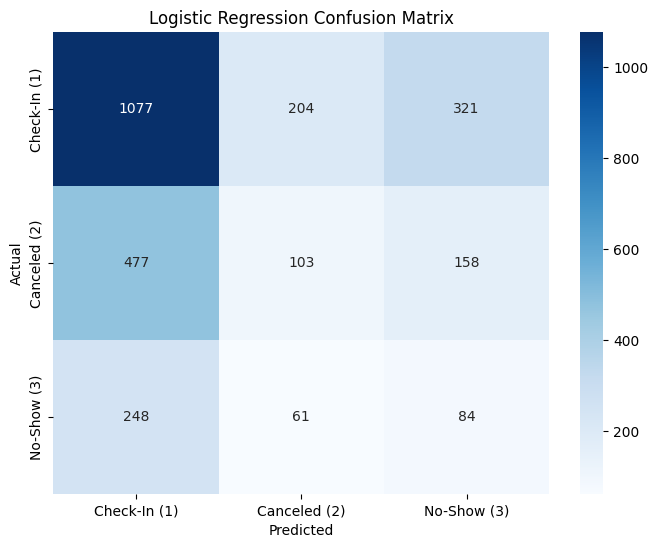

In [ ]:
# Plot the Confusion Matrix
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_val, y_pred_log)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Check-In (1)', 'Canceled (2)', 'No-Show (3)'],
            yticklabels=['Check-In (1)', 'Canceled (2)', 'No-Show (3)'])
plt.title('Logistic Regression Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()